# Plot map and overlay route

In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
from fit import fit_to_route
from geometry import Angle, Coord
from gpkg import GpkgMap
from matplotlib import pyplot as plt

In [2]:
# TODO: load the map according to the cue bearing
me = Coord(Angle(deg=51.75866), Angle(deg=-1.261))
bbox = np.concat([me.long_lat("°") - 0.005, me.long_lat("°") + 0.005])
oxford = gpd.read_file("oxfordshire.gpkg", layer="gis_osm_roads_free", bbox=tuple(bbox))
oxford

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry
0,2988197,5113,primary,Woodstock Road,A4144,B,48,0,F,F,"LINESTRING (-1.26371 51.76326, -1.26393 51.7636)"
1,2988251,5113,primary,St Giles',A4165,F,32,0,F,F,"LINESTRING (-1.26 51.75812, -1.25999 51.75814,..."
2,2988258,5122,residential,St Giles',,F,32,0,F,F,"LINESTRING (-1.25925 51.75524, -1.25926 51.755..."
3,2988259,5113,primary,Beaumont Street,A4144,B,32,0,F,F,"LINESTRING (-1.26295 51.75494, -1.2628 51.7549..."
4,2988267,5122,residential,Little Clarendon Street,,F,32,0,F,F,"LINESTRING (-1.26084 51.75888, -1.26099 51.758..."
...,...,...,...,...,...,...,...,...,...,...,...
910,1495027818,5153,footway,,,B,0,0,F,F,"LINESTRING (-1.25918 51.75638, -1.25908 51.756..."
911,1495027819,5153,footway,,,B,0,0,F,F,"LINESTRING (-1.25987 51.75908, -1.25985 51.758..."
912,1495160761,5153,footway,,,B,0,0,F,F,"LINESTRING (-1.25914 51.75606, -1.25925 51.756..."
913,1495160762,5153,footway,,,B,0,0,F,F,"LINESTRING (-1.25908 51.75606, -1.25912 51.75606)"


In [3]:
route = fit_to_route('stav_to_trin.fit')
cues = pd.read_csv('stav_to_trin_cuesheet.csv')
route.set_cues_text(cues['Notes'])
route.set_cues_icons(cues['Type'])
route.set_elevations(cues['Elevation (m)'])

route

Route stav-to-trin: 13 cues over 540.0s

In [4]:
instruction = route.instruct(me)
instruction

in 65m: (φ = 51.7585°, λ = -1.2605°) => Continue onto St Giles'

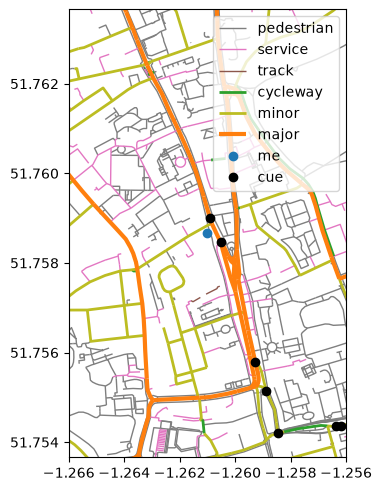

In [5]:
fig, ax = plt.subplots(1, 1, layout="constrained")
GpkgMap(oxford).plot_raw(ax, bbox, route.cues, me)

# Rotate projected map

array([[3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3]], shape=(296, 128))

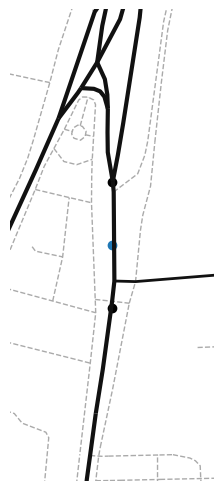

In [88]:
fig, ax = plt.subplots(1, 1, layout="constrained")
GpkgMap(oxford).plot_instruction(ax, instruction, 'grey')
fig.savefig('./inst.png', dpi=100, bbox_inches='tight')
rgba_pxs = plt.imread("inst.png")
grey_pxs = np.mean(rgba_pxs[:, :, :3], axis=2) * rgba_pxs[:, :, 3]
cropped_grey_pxs = np.array(grey_pxs[:296,:128] * 3, dtype=np.int64)
cropped_grey_pxs

# Display on e-paper

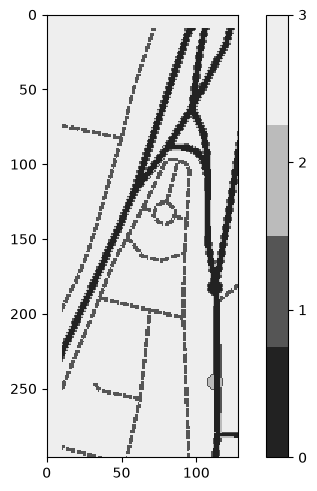

In [89]:
from epd_sim import Epd_Sim

epd = Epd_Sim()
epd.set_pixels(cropped_grey_pxs)

fig, ax = plt.subplots(1, 1, layout='constrained')
epd.display(ax)

---

# Rotate image

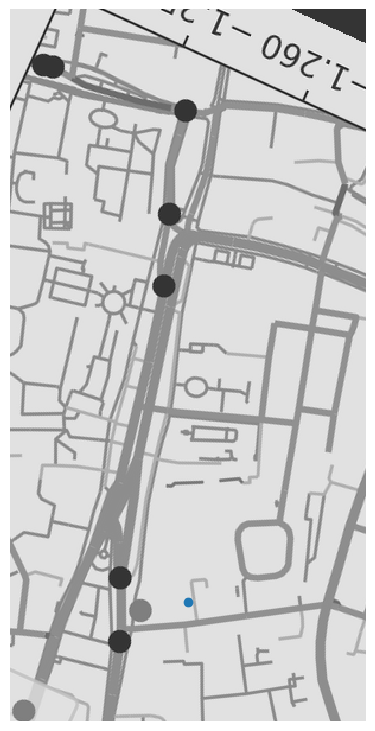

In [ ]:
from scipy.ndimage import rotate

rgba_pxs = plt.imread("map.png")
grey_pxs = np.mean(rgba_pxs[:, :, :3], axis=2) * rgba_pxs[:, :, 3]
m = rotate(grey_pxs, angle=instruction.bearing.deg)
rcy, rcx = np.array(m.shape) / 2  # rotated centre

fig, ax = plt.subplots(1, 1, figsize=(1.5 * 6.4, 1.5 * 4.8), layout="constrained")
ax.pcolormesh(m[::-1], cmap="gray")
ax.plot(rcx, rcy, "o")
ax.set_xlim(rcx - 150, rcx + 150)
ax.set_ylim(rcy - 100, rcy + 500)
ax.set_aspect("equal")
ax.set_axis_off()
plt.savefig("display.png", bbox_inches="tight")